In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings

from matplotlib import style
style.use('ggplot')

warnings.filterwarnings("ignore")

%matplotlib inline

<h1 style="text-align:center;">LEVEL 1</h1>

In [3]:
df = pd.read_csv("Dataset .csv")

In [4]:
df.head(1)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314


In [5]:
df.isna().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

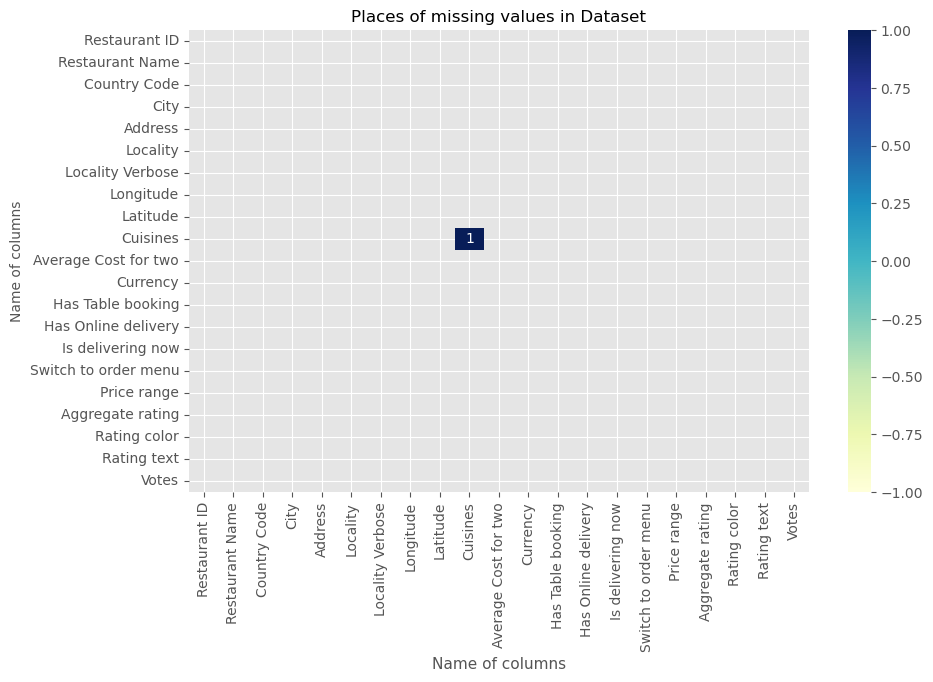

In [6]:
# Visualizing the missing values
# Checking Null Value by Plotting Heatmap

# Set the plot size
plt.figure(figsize=(10, 6))

# Create the figure object with a different color map (e.g., 'YlGnBu')
sns.heatmap(df.isnull().corr(), vmin=-1, annot=True, cmap='YlGnBu')

# Set labels
plt.xlabel('Name of columns', fontsize=11)
plt.ylabel('Name of columns', fontsize=10)
plt.title('Places of missing values in Dataset', fontsize=12)
plt.savefig("graph.png", dpi=300, bbox_inches='tight')
# To show
plt.show()

In [8]:
df.Cuisines.unique()

array(['French, Japanese, Desserts', 'Japanese',
       'Seafood, Asian, Filipino, Indian', ..., 'Burger, Izgara',
       'World Cuisine, Patisserie, Cafe', 'Italian, World Cuisine'],
      shape=(1826,), dtype=object)

In [9]:
df.Cuisines.mode()

0    North Indian
Name: Cuisines, dtype: object

In [10]:
df.Cuisines.mode()[0]

'North Indian'

In [11]:
df.Cuisines.replace(np.nan,df.Cuisines.mode()[0],inplace=True)

In [12]:
df.isna().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

# What did i found from the level 1 (task 1)?
- The restaurant dataset contains information about various restaurants across different cities. It includes details such as restaurant name, city, address, locality, cuisines, ratings, and price range, along with other attributes.

- The dataset consists of 9,551 rows and 21 columns.

- Missing values are found only in the cuisines column. Since the number of missing entries is very small (only 9), these rows will be removed to maintain data quality.

- There are no duplicate records in the dataset.

- No data type conversion is required as all columns are already in appropriate formats.

- The distribution of the target variable, Aggregate Rating, is fairly balanced.

# TASK 1
## Determine the top three most common cuisines in the dataset.

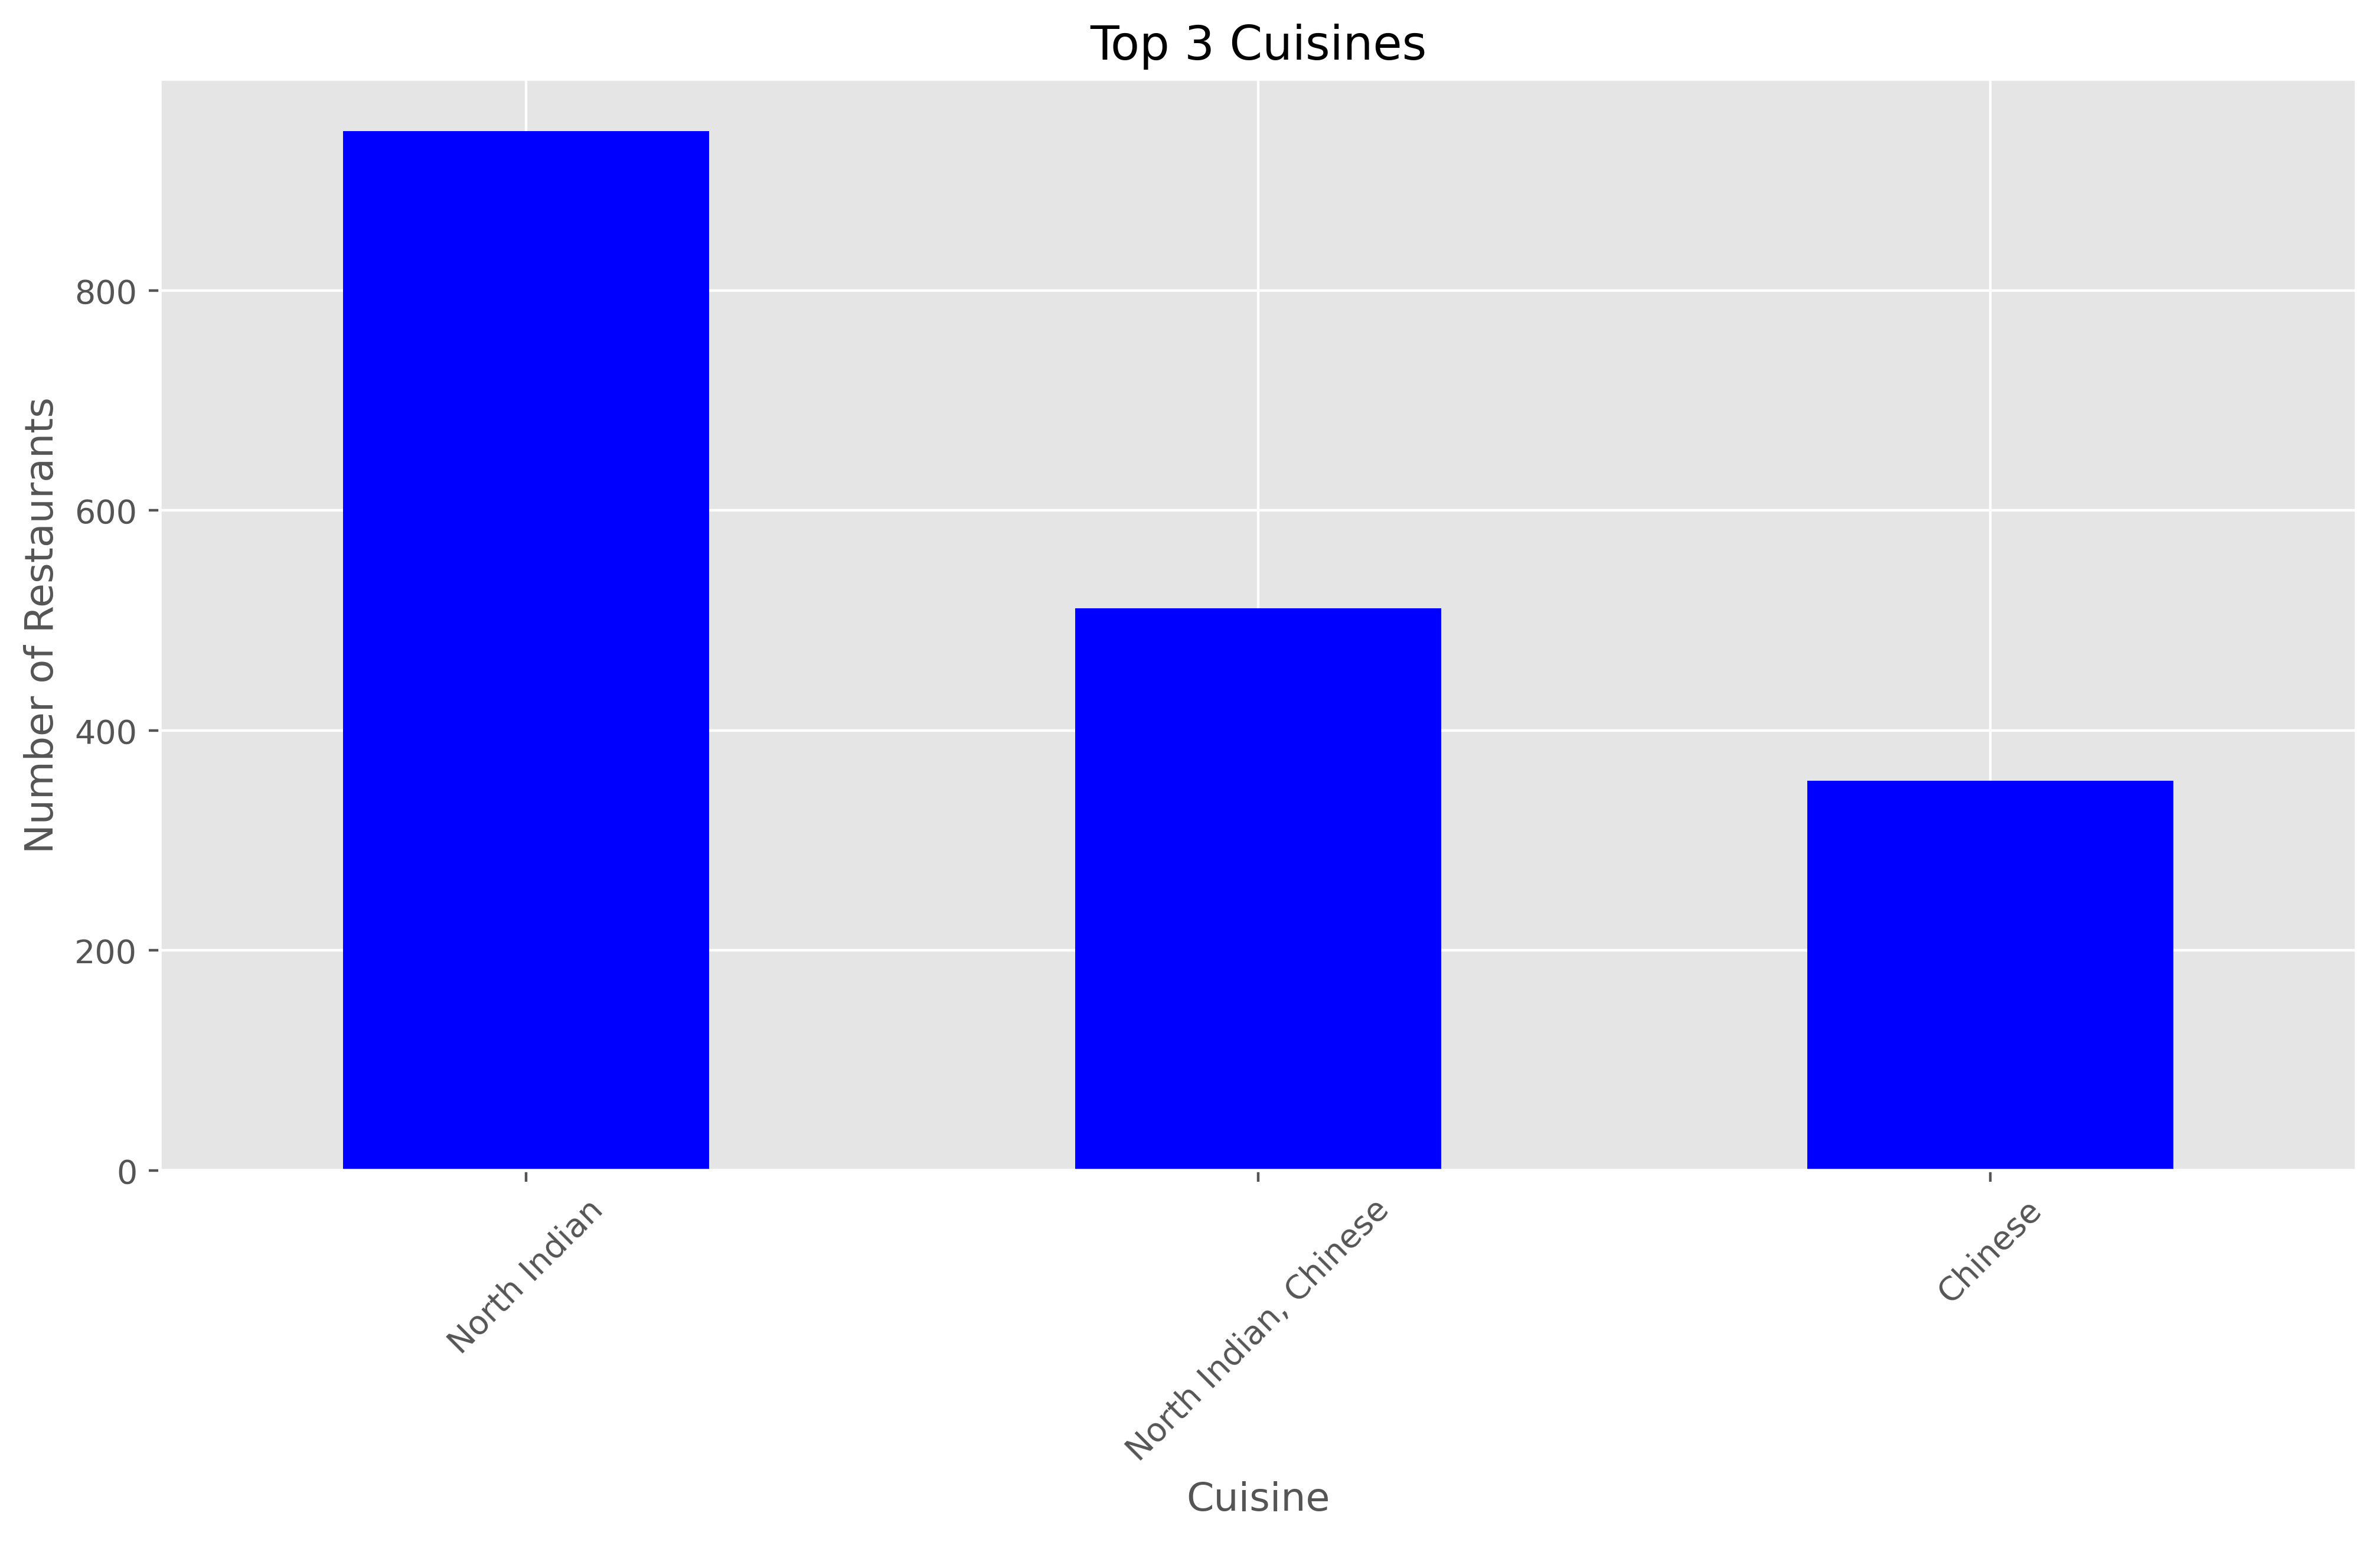

In [13]:
top_c = df["Cuisines"].value_counts().head(3)
top_c

# Plot
plt.figure(figsize = (12,6),dpi = 400)
top_c.plot(kind='bar',color = 'b')

plt.title("Top 3 Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

# Show plot
plt.show()

# Calculate the percentage of restaurants that serve each of the top cuisines.

In [14]:
cuisine_counts = df['Cuisines'].value_counts()
cuisine_percent = (cuisine_counts / len(df)) * 100
print(cuisine_percent)

Cuisines
North Indian                                             9.894252
North Indian, Chinese                                    5.350225
Chinese                                                  3.706418
Fast Food                                                3.706418
North Indian, Mughlai                                    3.497016
                                                           ...   
Bengali, Fast Food                                       0.010470
North Indian, Rajasthani, Asian                          0.010470
Chinese, Thai, Malaysian, Indonesian                     0.010470
Bakery, Desserts, North Indian, Bengali, South Indian    0.010470
Italian, World Cuisine                                   0.010470
Name: count, Length: 1825, dtype: float64


# TASK 2:- City Analysis
## 1:- Identify the city with the highest number of restaurants in the dataset.

In [15]:
df.head(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


In [16]:
city_counts = df['City'].value_counts()
top_city = city_counts.idxmax()
top_count = city_counts.max()

print("City:", top_city)
print("Number of Restaurants:", top_count)

City: New Delhi
Number of Restaurants: 5473


# 2:-Calculate the average rating for restaurants in each city.

In [17]:
avg_city = df.groupby('City')['Aggregate rating'].mean()
avg_city = avg_city.sort_values(ascending=False)
print(avg_city)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64


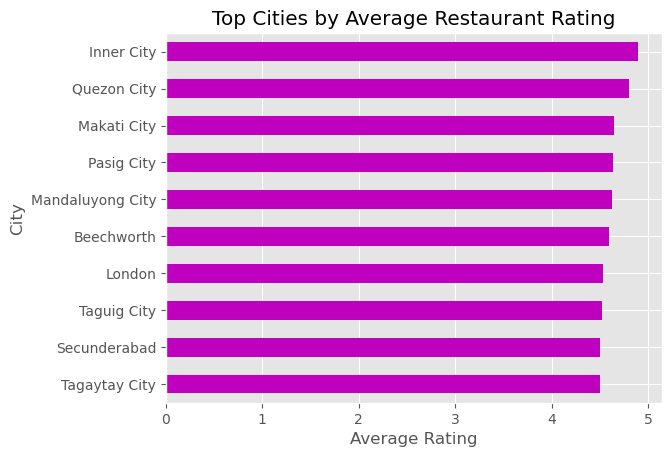

In [18]:
avg_city.head(10).sort_values().plot(kind='barh',color = "m")
plt.xlabel("Average Rating")
plt.ylabel("City")
plt.title("Top Cities by Average Restaurant Rating")
plt.savefig("graph.png", dpi=300, bbox_inches='tight')
plt.show()

# Determine the city with the highest average rating.

In [19]:
avg_rating_city = df.groupby('City')['Aggregate rating'].mean()

top_city = avg_rating_city.idxmax()
top_value = avg_rating_city.max()

print("City with the Highest Average :", top_city)
print("Highest Average Rating:", top_value)

City with the Highest Average : Inner City
Highest Average Rating: 4.9


# Task3 : Price Range Distribution

# Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants.

In [20]:
df.head(1)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314


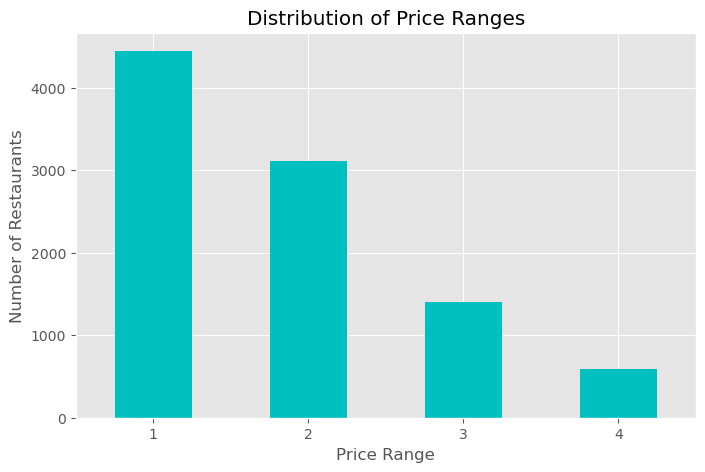

In [21]:

price_counts = df['Price range'].value_counts().sort_index()
price_counts

# Plot
plt.figure(figsize=(8,5))
price_counts.plot(kind='bar',color = 'c')

plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Price Ranges")

plt.xticks(rotation=0)
plt.show()

# Calculate the percentage of restaurants in each price range category.

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: proportion, dtype: float64


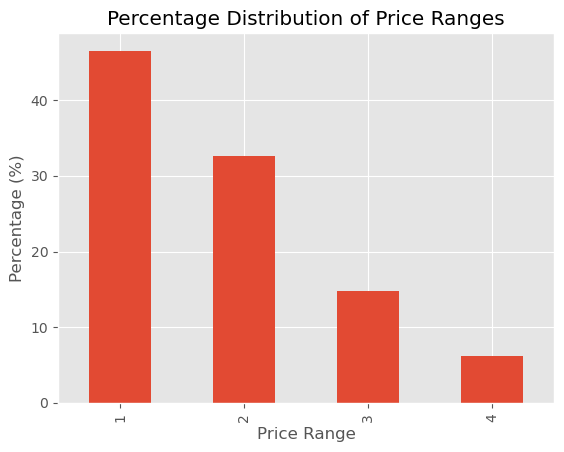

In [22]:
# Calculate percentage
price_percent = df['Price range'].value_counts(normalize=True) * 100

# Sort by price range
price_percent = price_percent.sort_index()

print(price_percent)
price_percent.plot(kind='bar')

plt.xlabel("Price Range")
plt.ylabel("Percentage (%)")
plt.title("Percentage Distribution of Price Ranges")

plt.show()

## The majority of restaurants fall under low and moderate price categories, with Price Range 1 having the highest share (48%), while high-end restaurants (Price Range 4) represent only a small portion (4%).

# Task 4: Online Delivery
## 1:- Determine the percentage of restaurants that offer online delivery.

In [23]:
df.head(1)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314


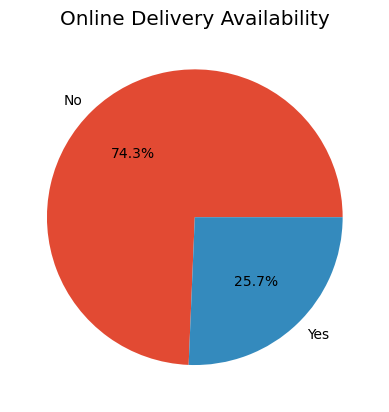

In [25]:
counts = df["Has Online delivery"].value_counts()

# Plot pie chart
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Online Delivery Availability")
plt.savefig("graph.png", dpi=300, bbox_inches='tight')
plt.show()

# Compare the average ratings of restaurants with and without online delivery.

In [103]:
avg_rating = df.groupby("Has Online delivery")["Aggregate rating"].mean()
print(avg_rating)

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


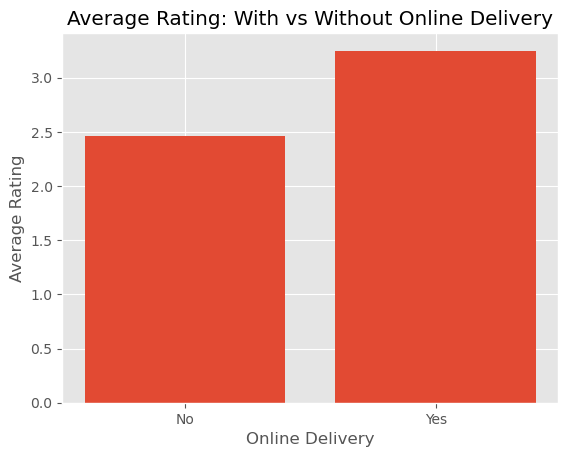

In [104]:
# Plot bar chart
plt.figure()
plt.bar(avg_rating.index, avg_rating.values)

plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")
plt.title("Average Rating: With vs Without Online Delivery")

plt.show()